# Analysis of DNS HTTPS RR Queries

The goal of this report is to help inform the decision of enabling the HTTPS RR or ECH in networking libraries by default.

It queries DNS for the A, AAAA and HTTPS resource records of the top N domains from the Tranco list.
It then analyzes the performance of the HTTPS resource records.

## Set up

In [1]:
topN = 10000
numQueries = 3

In [4]:
!go run . -workspace ../workspace -topN {topN} -numQueries {numQueries} 2> log.txt

In [6]:
!cp ../workspace/results-top{topN}-n{numQueries}.csv ../workspace/domains-top{topN}.csv .

## Load Data

Output the number of responses and domains into SUCCESS and FAILED categories. SUCCESS is broken down into whether it has answers and no answers. FAILED is broken down into TIMEOUT and specific rcode errors.

In [17]:
import pandas as pd
import json

# Ensure we're using the latest data file
latest_file = f'./results-top{topN}-n{numQueries}.csv'
df = pd.read_csv(latest_file)

# Drop invalid domains that failed to resolve during the initial annotation phase
print(f"Total Unique Domains Analysed: {df['domain'].nunique()}")
df = df.dropna(subset=['domain'])
print(f"Total Unique Valid Domains Analysed: {df['domain'].nunique()}")

# Drop all the domains with NXDOMAIN in the rcode
nxdomain_domains = df[df['rcode'] == 'NXDOMAIN']['domain'].unique()
df = df[~df['domain'].isin(nxdomain_domains)]
print(f"Total Unique Valid Domains without NXDOMAIN: {df['domain'].nunique()}")

def categorize_response(row):
    err = str(row['error']).lower()
    rcode = str(row['rcode']) if pd.notna(row['rcode']) else 'UNKNOWN'
    
    # Check for network-level/dial errors first
    if not pd.isna(row['error']):
        if 'timeout' in err or 'timedout' in err:
            return "ERROR - TIMEOUT"
        else:
            return f"ERROR - {rcode}"
    
    # Then check for DNS-level error responses (e.g. SERVFAIL, NXDOMAIN)
    if rcode != 'NOERROR':
        return f"ERROR - {rcode}"
        
    # Success (rcode is NOERROR and no network-level error)
    ans_len = 0
    if isinstance(row['answers'], str) and row['answers'].startswith('['):
        try:
            ans_len = len(json.loads(row['answers']))
        except:
            pass
    
    if ans_len > 0:
        return "SUCCESS - has answers"
    else:
        return "SUCCESS - no answers"

df['category'] = df.apply(categorize_response, axis=1)
df['status'] = df['category'].apply(lambda x: x.split(' - ')[0])

Total Unique Domains Analysed: 9954
Total Unique Valid Domains Analysed: 9954
Total Unique Valid Domains without NXDOMAIN: 9892


In [19]:
def display_with_pct(ct):
    totals = ct.loc['Total']
    pcts = ct.div(totals, axis=1) * 100
    out = pd.DataFrame(index=ct.index, columns=ct.columns)
    for c in ct.columns:
        out[c] = ct[c].map(lambda x: f"{int(x):,}") + " (" + pcts[c].map(lambda x: f"{x:.1f}%") + ")"
    display(out)


print("\nNumber of Responses by Status (Success vs Error):")
ct_status = pd.crosstab(df['status'], df['query_type'], margins=True, margins_name="Total")
display_with_pct(ct_status)

print("\nNumber of Responses by Detailed Category:")
ct_category = pd.crosstab(df['category'], df['query_type'], margins=True, margins_name="Total")
display_with_pct(ct_category)

# Calculate true unique domains queried overall for each query_type and overall
total_domains = df.groupby('query_type')['domain'].nunique()
total_domains['Total'] = df['domain'].nunique()

print("\nNumber of Domains by Status (Success vs Error):")
domain_status_summary = df.groupby(['status', 'query_type'])['domain'].nunique().unstack(level='query_type').fillna(0).astype(int)
domain_status_summary['Total'] = df.groupby('status')['domain'].nunique()
domain_status_summary.loc['Total'] = total_domains
display_with_pct(domain_status_summary)

print("\nNumber of Domains by Detailed Category:")
# Calculate unique domains per category per query type
domain_summary = df.groupby(['category', 'query_type'])['domain'].nunique().unstack(level='query_type').fillna(0).astype(int)
domain_summary['Total'] = df.groupby('category')['domain'].nunique()
domain_summary.loc['Total'] = total_domains
display_with_pct(domain_summary)


Number of Responses by Status (Success vs Error):


query_type,A,AAAA,HTTPS,Total
status,,,,
ERROR,184 (0.6%),188 (0.6%),255 (0.9%),627 (0.7%)
SUCCESS,"29,492 (99.4%)","29,488 (99.4%)","29,421 (99.1%)","88,401 (99.3%)"
Total,"29,676 (100.0%)","29,676 (100.0%)","29,676 (100.0%)","89,028 (100.0%)"



Number of Responses by Detailed Category:


query_type,A,AAAA,HTTPS,Total
category,,,,
ERROR - SERVFAIL,62 (0.2%),64 (0.2%),121 (0.4%),247 (0.3%)
ERROR - TIMEOUT,122 (0.4%),124 (0.4%),134 (0.5%),380 (0.4%)
SUCCESS - has answers,"24,496 (82.5%)","9,027 (30.4%)","4,396 (14.8%)","37,919 (42.6%)"
SUCCESS - no answers,"4,996 (16.8%)","20,461 (68.9%)","25,025 (84.3%)","50,482 (56.7%)"
Total,"29,676 (100.0%)","29,676 (100.0%)","29,676 (100.0%)","89,028 (100.0%)"



Number of Domains by Status (Success vs Error):


query_type,A,AAAA,HTTPS,Total
status,,,,
ERROR,130 (1.3%),134 (1.4%),162 (1.6%),204 (2.1%)
SUCCESS,"9,866 (99.7%)","9,866 (99.7%)","9,846 (99.5%)","9,866 (99.7%)"
Total,"9,892 (100.0%)","9,892 (100.0%)","9,892 (100.0%)","9,892 (100.0%)"



Number of Domains by Detailed Category:


query_type,A,AAAA,HTTPS,Total
category,,,,
ERROR - SERVFAIL,21 (0.2%),24 (0.2%),48 (0.5%),51 (0.5%)
ERROR - TIMEOUT,109 (1.1%),111 (1.1%),117 (1.2%),157 (1.6%)
SUCCESS - has answers,"8,193 (82.8%)","3,023 (30.6%)","1,470 (14.9%)","8,195 (82.8%)"
SUCCESS - no answers,"1,674 (16.9%)","6,851 (69.3%)","8,380 (84.7%)","8,673 (87.7%)"
Total,"9,892 (100.0%)","9,892 (100.0%)","9,892 (100.0%)","9,892 (100.0%)"


## Latency Analysis
The following cell dynamically loads the most recent query results and visualizes the DNS query latency (`duration_ms`) by query type (`A`, `AAAA`, `HTTPS`). It scales based on the number of domains and runs. It produces a Boxplot to check for outliers and interquartile range differences, and a Cumulative Distribution Function (CDF) plot for a fine-grained view of the latency distribution.

Excluded 627 failed queries. Proceeding with 88401 successful queries.
Dataset contains 9866 unique domains and 3 runs.


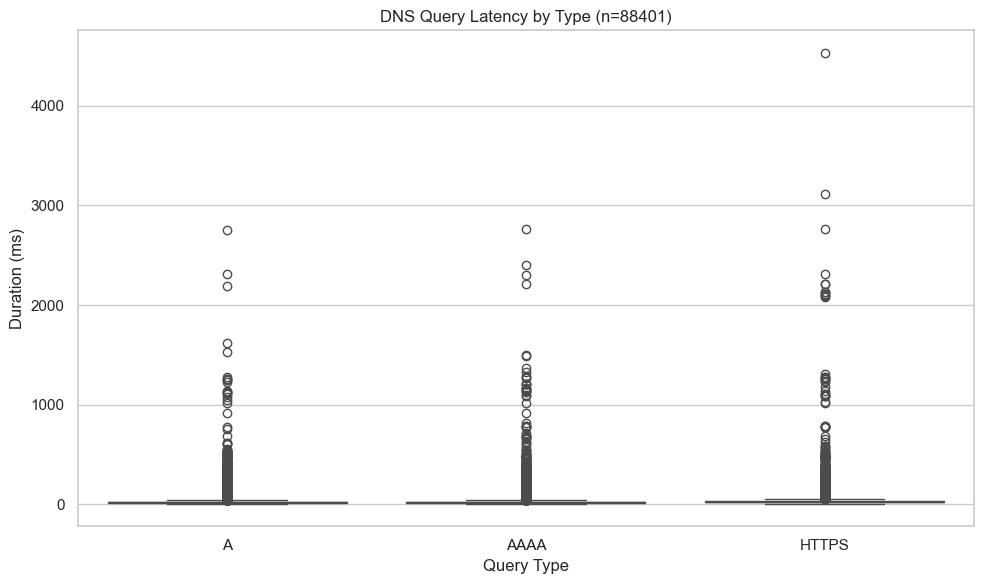

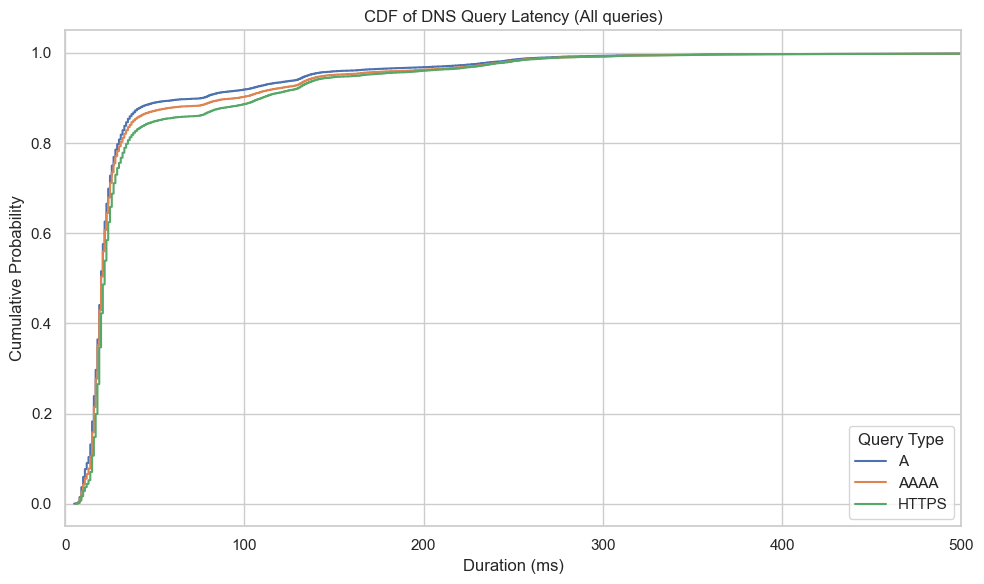

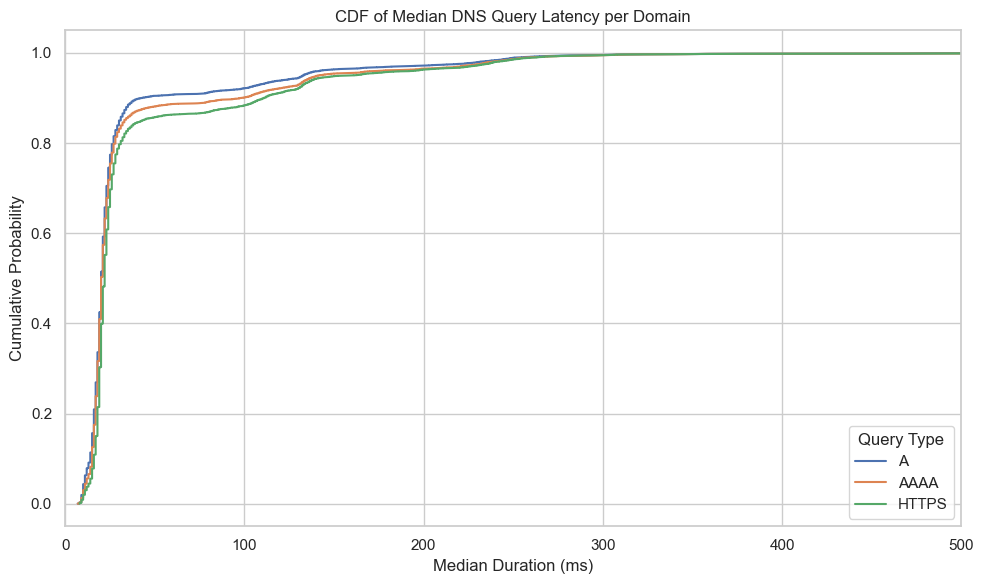

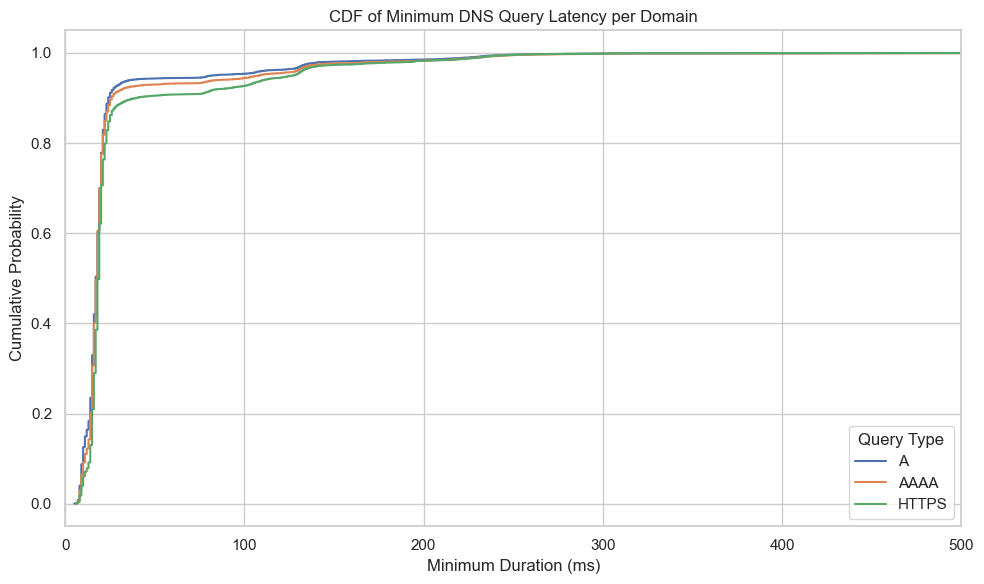


Summary Statistics of Latency (ms):


,count,mean,std,min,25%,50%,75%,max
query_type,,,,,,,,
A,29492.0,36.369219,63.261321,5.0,17.0,20.0,27.0,2755.0
AAAA,29488.0,39.447165,69.694172,6.0,17.0,20.0,27.0,2762.0
HTTPS,29421.0,43.294959,81.281130,6.0,18.0,22.0,30.0,4531.0


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot only the successful queries (filtering out DNS and network errors)
df_success = df[df['status'] == 'SUCCESS'].copy()
print(f"Excluded {len(df) - len(df_success)} failed queries. Proceeding with {len(df_success)} successful queries.")

# Extract number of domains and runs from filename or data
num_domains = df_success['rank'].nunique()
num_runs = df_success['run'].nunique()
print(f"Dataset contains {num_domains} unique domains and {num_runs} runs.")

# Configure aesthetics
sns.set_theme(style="whitegrid")

# 1. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_success, x='query_type', y='duration_ms')
plt.title(f'DNS Query Latency by Type (n={len(df_success)})')
plt.ylabel('Duration (ms)')
plt.xlabel('Query Type')
plt.tight_layout()
plt.show()

# 2. CDF Plot of all queries
plt.figure(figsize=(10, 6))
for qt, group in df_success.groupby('query_type'):
    x = np.sort(group['duration_ms'])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=qt)

plt.title('CDF of DNS Query Latency (All queries)')
plt.xlabel('Duration (ms)')
plt.ylabel('Cumulative Probability')
plt.xlim(0, 500)
plt.legend(title='Query Type')
plt.tight_layout()
plt.show()

# 3. CDF of median latency per domain
plt.figure(figsize=(10, 6))
median_df = df_success.groupby(['domain', 'query_type'])['duration_ms'].median().reset_index()
for qt, group in median_df.groupby('query_type'):
    x = np.sort(group['duration_ms'])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=qt)

plt.title('CDF of Median DNS Query Latency per Domain')
plt.xlabel('Median Duration (ms)')
plt.ylabel('Cumulative Probability')
plt.xlim(0, 500)
plt.legend(title='Query Type')
plt.tight_layout()
plt.show()

# 4. CDF of minimum latency per domain
plt.figure(figsize=(10, 6))
min_df = df_success.groupby(['domain', 'query_type'])['duration_ms'].min().reset_index()
for qt, group in min_df.groupby('query_type'):
    x = np.sort(group['duration_ms'])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=qt)

plt.title('CDF of Minimum DNS Query Latency per Domain')
plt.xlabel('Minimum Duration (ms)')
plt.ylabel('Cumulative Probability')
plt.xlim(0, 500)
plt.legend(title='Query Type')
plt.tight_layout()
plt.show()

# Print summary statistics
summary_stats = df_success.groupby('query_type')['duration_ms'].describe()
print("\nSummary Statistics of Latency (ms):")
display(summary_stats)

## Slow Queries Analysis

The following table shows the top 20 slowest queries across all runs.

In [42]:
# Identify the slowest queries among the successful ones
slow_queries = df_success.sort_values(by='duration_ms', ascending=False).head(20)

print("\nTop 20 Slowest Successful Queries:")
display(slow_queries[['domain', 'rank', 'query_type', 'duration_ms', 'nameservers']].reset_index(drop=True))


Top 20 Slowest Successful Queries:


,domain,rank,query_type,duration_ms,nameservers
0,midea.com,3439,HTTPS,4531,"[""gtmcnc.midea.com.cn."",""gtmct.midea.com.cn."",..."
1,uva.nl,9122,HTTPS,3111,"[""ns1.uha.nl."",""ns1.zurich.surf.net."",""ns2.uha..."
2,kerala.gov.in,8067,AAAA,2762,"[""ns1.cdit.org."",""ns2.cdit.org."",""ns3.cdit.org.""]"
3,kerala.gov.in,8067,HTTPS,2759,"[""ns1.cdit.org."",""ns2.cdit.org."",""ns3.cdit.org.""]"
4,kerala.gov.in,8067,A,2755,"[""ns1.cdit.org."",""ns2.cdit.org."",""ns3.cdit.org.""]"
5,midea.com,3439,AAAA,2402,"[""gtmcnc.midea.com.cn."",""gtmct.midea.com.cn."",..."
6,pmkisan.gov.in,2182,A,2315,"[""ns1.nic.in."",""ns10.nic.in."",""ns2.nic.in."",""n..."
7,cnmsn.net,8879,HTTPS,2314,"[""dns.bizcn.com."",""dns.cnmsn.net."",""ns1.4everd..."
8,uucms.karnataka.gov.in,2668,AAAA,2302,"[""ns1.nic.in."",""ns10.nic.in."",""ns2.nic.in."",""n..."
9,myqnapcloud.com,6337,HTTPS,2210,"[""ns1.myqnapcloud.com."",""ns2.myqnapcloud.com.""..."


## Performance Impact of HTTPS RR

This analysis identifies when waiting for an HTTPS RR delays connection establishment. The **HTTPS Delay** is calculated as the difference between the HTTPS completion time and a standard "legacy" connection baseline.

**How the Baseline is Calculated (Happy Eyeballs V2 - RFC 8305):**
To accurately model modern connection logic, the baseline start time isn't just the absolute minimum of A and AAAA arrival times. It factors in whether the records contain actual answers and respects the IPv6 preference resolution delay (50ms):
* **If only AAAA has answers:** The connection starts immediately when AAAA arrives.
* **If only A has answers:** If A arrives first, the client waits up to 50ms (*Resolution Delay*) for the AAAA response. If an empty AAAA response arrives within that window, the connection starts immediately at that point. Otherwise, it starts at `A + 50ms`.
* **If both have answers:** The connection starts with AAAA if it arrives within 50ms of A. If AAAA is slower than `A + 50ms`, the connection starts with A at `A + 50ms`.

Cases introducing >50ms delays or experiencing run-time timeouts on HTTPS specifically are grouped by the nameserver providers to identify systemic issues.

In [43]:
import json

# Start with the original df to include timeouts and errors
# Pivot durations and errors by domain and run
pivot_dur = df.pivot_table(index=['domain', 'run', 'rank'], columns='query_type', values='duration_ms', aggfunc='min').reset_index()

# Use groupby.unstack for the string 'error' column. 
# Using pivot_table on a mostly-NaN column trims the frame due to default dropna=True
pivot_err = df.groupby(['domain', 'run', 'rank', 'query_type'])['error'].first().unstack('query_type').reset_index()
pivot_cat = df.groupby(['domain', 'run', 'rank', 'query_type'])['category'].first().unstack('query_type').reset_index()

# Ensure A, AAAA, and HTTPS columns exist
for qt in ['A', 'AAAA', 'HTTPS']:
    if qt not in pivot_dur.columns:
        pivot_dur[qt] = np.nan
    if qt not in pivot_err.columns:
        pivot_err[qt] = np.nan
    if qt not in pivot_cat.columns:
        pivot_cat[qt] = np.nan

pivot_dur['cat_A'] = pivot_cat['A']
pivot_dur['cat_AAAA'] = pivot_cat['AAAA']

# Calculate standard legacy connections baseline, accounting for Happy Eyeballs V2 (RFC 8305)
# Waiting up to a 50ms Resolution Delay for AAAA but only if it contains actual records
def calc_he_baseline(row):
    t_a = row['A']
    t_aaaa = row['AAAA']
    
    h_a = row['cat_A'] == 'SUCCESS - has answers'
    h_aaaa = row['cat_AAAA'] == 'SUCCESS - has answers'
    
    if not h_a and not h_aaaa:
        return np.nan
        
    if h_a and not h_aaaa:
        if pd.isna(t_aaaa): # No response for AAAA yet, wait up to 50ms
            return t_a + 50
        return max(t_a, min(t_a + 50, t_aaaa)) # Wait until we know AAAA is empty, or timer fires
        
    if not h_a and h_aaaa:
        return t_aaaa # Use AAAA immediately
        
    # Both have answers
    if pd.isna(t_aaaa):
        return t_a + 50
    if pd.isna(t_a):
        return t_aaaa
        
    if t_aaaa <= t_a + 50:
        return t_aaaa
    return t_a + 50

pivot_dur['min_a_aaaa'] = pivot_dur.apply(calc_he_baseline, axis=1)
pivot_dur['https_delay'] = pivot_dur['HTTPS'] - pivot_dur['min_a_aaaa']

# Identify fail-open scenarios: where HTTPS errored/timed out but A or AAAA succeeded
pivot_err['https_error'] = pivot_err['HTTPS'].notna()
pivot_err['a_aaaa_success'] = pivot_err['A'].isna() | pivot_err['AAAA'].isna()
pivot_err['https_timeout_failopen'] = pivot_err['https_error'] & pivot_err['a_aaaa_success']

# Merge latency and error information
combined = pd.merge(pivot_dur, pivot_err[['domain', 'run', 'https_error', 'a_aaaa_success', 'https_timeout_failopen']], on=['domain', 'run'])

# Filter cases exceeding the 50ms performance threshold or timing out entirely
hurt_perf = combined[(combined['https_delay'] > 50) | combined['https_timeout_failopen']].copy()

print(f"Total domains where waiting for HTTPS hurts performance (>50ms delay or timeout): {len(hurt_perf)} out of {len(combined)}")

# Grouping worst offenders by Nameserver Providers
def extract_primary_ns(ns_str):
    try:
        ns_list = json.loads(ns_str)
        if ns_list and len(ns_list) > 0:
            ns = ns_list[0].strip('.')
            parts = ns.split('.')
            if len(parts) >= 2:
                return '.'.join(parts[-2:])
            return ns
    except:
        pass
    return "Unknown"

# Fetch nameservers from the earliest valid row per domain
domain_ns = df.dropna(subset=['nameservers']).groupby('domain')['nameservers'].first().reset_index()
domain_ns['ns_provider'] = domain_ns['nameservers'].apply(extract_primary_ns)

# Merge nameserver grouping back into the hurt_perf dataframe
hurt_perf = hurt_perf.merge(domain_ns[['domain', 'ns_provider']], on='domain', how='left')

# Output the worst nameservers 
worst_ns = hurt_perf.groupby('ns_provider').size().reset_index(name='count').sort_values(by='count', ascending=False)
print("\nTop 20 Nameserver Providers responsible for performance-hurting HTTPS responses:")
display(worst_ns.head(20).reset_index(drop=True))

# Output top specific domains 
print("\nTop 20 Specific Domains with the Highest HTTPS Delay:")
top_delayed_domains = hurt_perf.sort_values(by='https_delay', ascending=False)[['domain', 'rank', 'https_delay', 'ns_provider']].head(20).reset_index(drop=True)
display(top_delayed_domains)

Total domains where waiting for HTTPS hurts performance (>50ms delay or timeout): 1654 out of 29676

Top 20 Nameserver Providers responsible for performance-hurting HTTPS responses:


,ns_provider,count
0,cloudflare.com,53
1,alidns.com,39
2,nic.ru,33
3,co.kr,29
4,nic.in,22
5,co.jp,21
6,alibabadns.com,18
7,ne.jp,17
8,gov.in,15
9,akam.net,13



Top 20 Specific Domains with the Highest HTTPS Delay:


,domain,rank,https_delay,ns_provider
0,pubmed.ncbi.nlm.nih.gov,500,4995.0,nih.gov
1,pushy.io,4360,4993.0,pushy.me
2,pushy.io,4360,4986.0,pushy.me
3,nj.com,5487,4982.0,nsone.net
4,unagi.amazon.com,8093,4981.0,awsdns-34.org
5,cancer.gov,4369,4980.0,nih.gov
6,wikiquote.org,7095,4978.0,wikimedia.org
7,iastate.edu,5264,4977.0,iastate.edu
8,match.com,5541,4976.0,nsone.net
9,pushy.io,4360,4976.0,pushy.me


## Total HTTPS Wait Delay Distribution

While the section above focused just on performance *hits*, let's visualize the delay that waiting for the `HTTPS` record introduced across all domains. This gives a view of whether the delay is generally around zero (resolving at the same time), negative (where HTTPS is unexpectedly faster), or significantly delayed across the board.

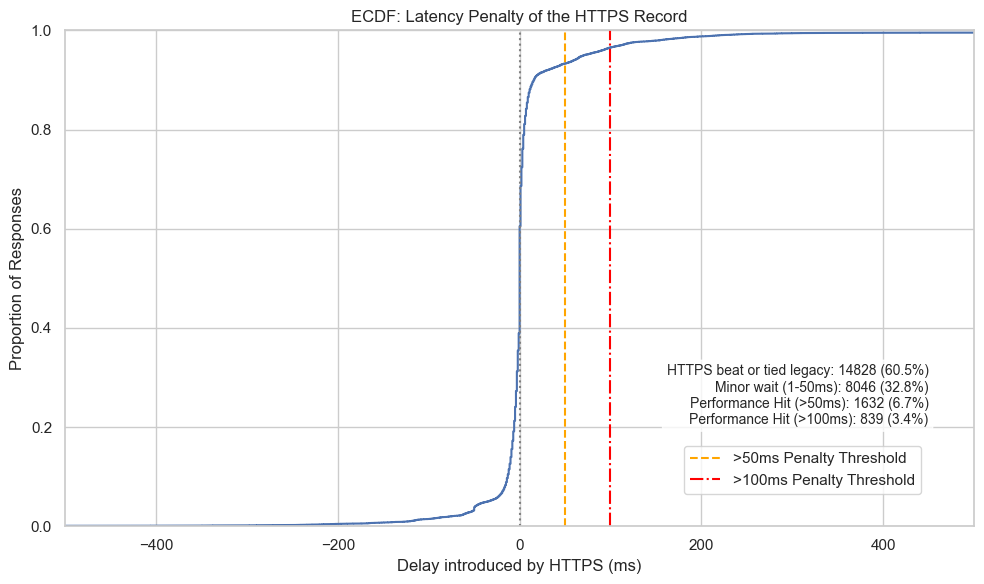

In [13]:
all_delays = combined['https_delay'].dropna()

# Empirical Cumulative Distribution Function of the general delay
plt.figure(figsize=(10, 6))
sns.ecdfplot(all_delays)
plt.title('ECDF: Latency Penalty of the HTTPS Record')
plt.xlabel('Delay introduced by HTTPS (ms)')
plt.ylabel('Proportion of Responses')
plt.xlim(-500, 500)
plt.axvline(x=0, color='gray', linestyle=':')
plt.axvline(x=50, color='orange', linestyle='--', label='>50ms Penalty Threshold')
plt.axvline(x=100, color='red', linestyle='-.', label='>100ms Penalty Threshold')

# Calculate percentages explicitly
total_valid = len(all_delays)
pct_fast_or_same = len(all_delays[all_delays <= 0]) / total_valid * 100
pct_slow_under_50 = len(all_delays[(all_delays > 0) & (all_delays <= 50)]) / total_valid * 100
pct_slow_over_50 = len(all_delays[all_delays > 50]) / total_valid * 100
pct_slow_over_100 = len(all_delays[all_delays > 100]) / total_valid * 100

stats_text = (f"HTTPS beat or tied legacy: {len(all_delays[all_delays <= 0])} ({pct_fast_or_same:.1f}%)\n"
              f"Minor wait (1-50ms): {len(all_delays[(all_delays > 0) & (all_delays <= 50)])} ({pct_slow_under_50:.1f}%)\n"
              f"Performance Hit (>50ms): {len(all_delays[all_delays > 50])} ({pct_slow_over_50:.1f}%)\n"
              f"Performance Hit (>100ms): {len(all_delays[all_delays > 100])} ({pct_slow_over_100:.1f}%)")

plt.text(0.95, 0.20, stats_text, 
         transform=plt.gca().transAxes, 
         fontsize=10, 
         verticalalignment='bottom', 
         horizontalalignment='right', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.05))
plt.tight_layout()
plt.show()

## HTTPS Wait Delay Distribution (For domains with an HTTPS RR)

Now let's filter and look at the exact same delay distribution, but *only* for domains that actually served an `HTTPS` record successfully. Domains that return `NXDOMAIN` (no record exists) typically fail very fast and might skew the perceived performance if we are trying to measure how long a *real* HTTPS RR takes to be served.

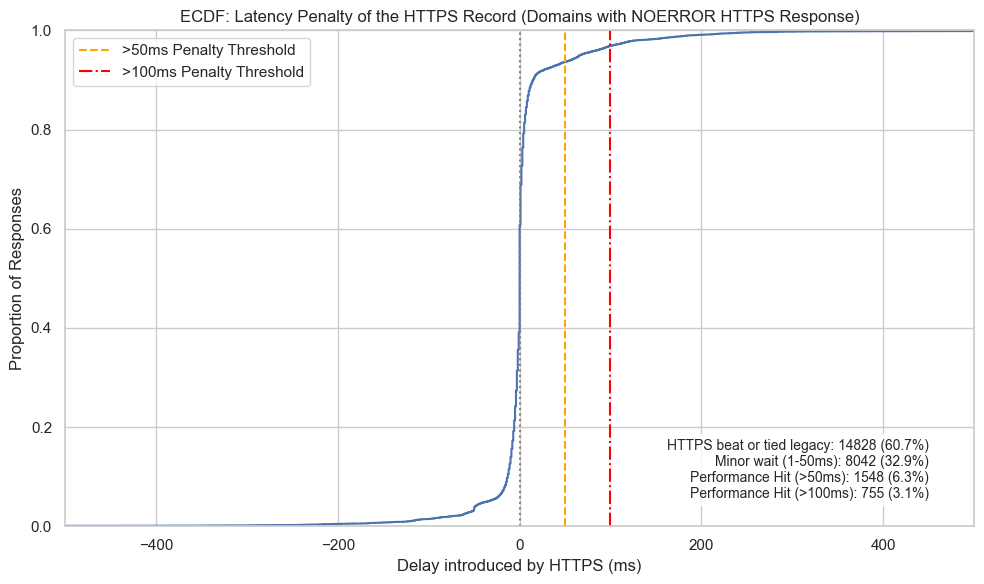

In [18]:
# Only consider rows where HTTPS queries returned successfully (NOERROR means both no timeout/dial error and no DNS error like NXDOMAIN)
https_success_domains = df[(df['query_type'] == 'HTTPS') & (df['error'].isna()) & (df['rcode'] == 'NOERROR')][['domain', 'run']]

# Filter our combined latency DataFrame down to just these known-good domains
combined_success = pd.merge(combined, https_success_domains, on=['domain', 'run'])

has_https_delays = combined_success['https_delay'].dropna()

plt.figure(figsize=(10, 6))
sns.ecdfplot(has_https_delays)
plt.title('ECDF: Latency Penalty of the HTTPS Record (Domains with NOERROR HTTPS Response)')
plt.xlabel('Delay introduced by HTTPS (ms)')
plt.ylabel('Proportion of Responses')
plt.xlim(-500, 500)
plt.axvline(x=0, color='gray', linestyle=':')
plt.axvline(x=50, color='orange', linestyle='--', label='>50ms Penalty Threshold')
plt.axvline(x=100, color='red', linestyle='-.', label='>100ms Penalty Threshold')

# Calculate percentages explicitly
total_valid = len(has_https_delays)
if total_valid > 0:
    pct_fast_or_same = len(has_https_delays[has_https_delays <= 0]) / total_valid * 100
    pct_slow_under_50 = len(has_https_delays[(has_https_delays > 0) & (has_https_delays <= 50)]) / total_valid * 100
    pct_slow_over_50 = len(has_https_delays[has_https_delays > 50]) / total_valid * 100
    pct_slow_over_100 = len(has_https_delays[has_https_delays > 100]) / total_valid * 100

    stats_text = (f"HTTPS beat or tied legacy: {len(has_https_delays[has_https_delays <= 0])} ({pct_fast_or_same:.1f}%)\n"
                f"Minor wait (1-50ms): {len(has_https_delays[(has_https_delays > 0) & (has_https_delays <= 50)])} ({pct_slow_under_50:.1f}%)\n"
                f"Performance Hit (>50ms): {len(has_https_delays[has_https_delays > 50])} ({pct_slow_over_50:.1f}%)\n"
                f"Performance Hit (>100ms): {len(has_https_delays[has_https_delays > 100])} ({pct_slow_over_100:.1f}%)")

    plt.text(0.95, 0.05, stats_text, 
            transform=plt.gca().transAxes, 
            fontsize=10, 
            verticalalignment='bottom', 
            horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## The Case for HTTP/3 over QUIC (alpn=h3)

The `HTTPS` resource record provides a mechanism for servers to announce support for HTTP/3 (`h3`) over QUIC via DNS, using the `alpn` parameter. By discovering this support before initiating a connection, clients can bypass the traditional TCP and TLS handshakes, as well as the subsequent `Alt-Svc` header upgrade process.

Connecting directly via QUIC over UDP typically saves at least one full round-trip time (RTT) during connection establishment, offering noticeable latency improvements. The following analysis isolates the domains that explicitly announce `h3` support to evaluate whether the time spent waiting for the `HTTPS` record is offset by the capabilities it unlocks.

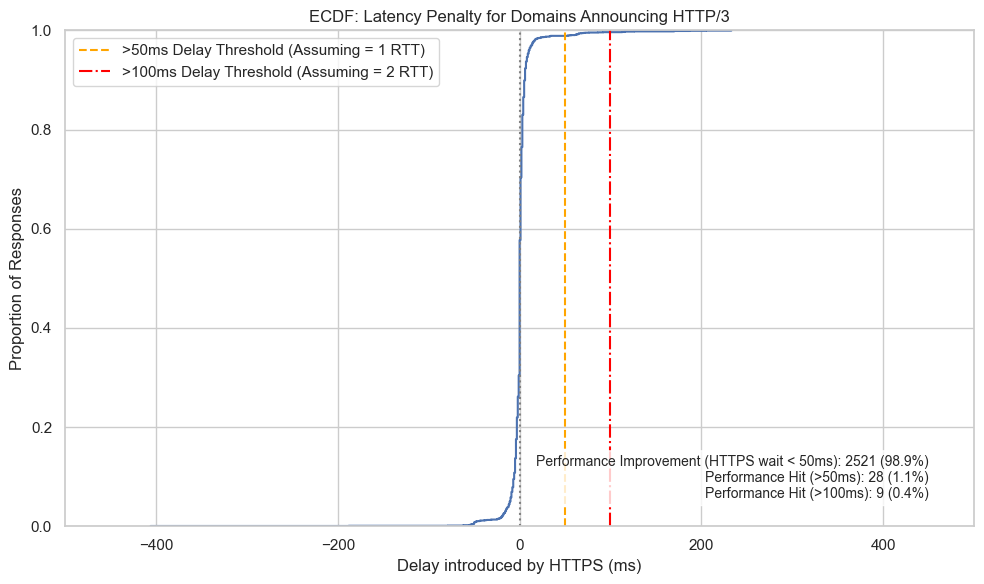

In [21]:
# Filter for domains with h3 support explicitly in their ALPN of the HTTPS RR
h3_domains = df[(df['query_type'] == 'HTTPS') & (~df['answers'].isna()) & (df['answers'].str.contains('h3', case=False, na=False))][['domain', 'run']]

combined_h3 = pd.merge(combined_success, h3_domains, on=['domain', 'run'])

h3_delays = combined_h3['https_delay'].dropna()

plt.figure(figsize=(10, 6))
sns.ecdfplot(h3_delays)
plt.title('ECDF: Latency Penalty for Domains Announcing HTTP/3')
plt.xlabel('Delay introduced by HTTPS (ms)')
plt.ylabel('Proportion of Responses')
plt.xlim(-500, 500)
plt.axvline(x=0, color='gray', linestyle=':')
plt.axvline(x=50, color='orange', linestyle='--', label='>50ms Delay Threshold (Assuming = 1 RTT)')
plt.axvline(x=100, color='red', linestyle='-.', label='>100ms Delay Threshold (Assuming = 2 RTT)')

# Calculate percentages explicitly around the 50ms RTT threshold
total_valid_h3 = len(h3_delays)
if total_valid_h3 > 0:
    pct_improvement = len(h3_delays[h3_delays <= 50]) / total_valid_h3 * 100
    pct_hit_over_50 = len(h3_delays[h3_delays > 50]) / total_valid_h3 * 100
    pct_hit_over_100 = len(h3_delays[h3_delays > 100]) / total_valid_h3 * 100

    stats_text_h3 = (f"Performance Improvement (HTTPS wait < 50ms): {len(h3_delays[h3_delays <= 50])} ({pct_improvement:.1f}%)\n"
                 f"Performance Hit (>50ms): {len(h3_delays[h3_delays > 50])} ({pct_hit_over_50:.1f}%)\n"
                 f"Performance Hit (>100ms): {len(h3_delays[h3_delays > 100])} ({pct_hit_over_100:.1f}%)")

    plt.text(0.95, 0.05, stats_text_h3, 
             transform=plt.gca().transAxes, 
             fontsize=10, 
             verticalalignment='bottom', 
             horizontalalignment='right', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()